In [1]:
import os
import glob
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import model_inference


In [2]:
# Build a .py script that takes a snapshot date, loads a model artefact and make an inference and save to datamart

## set up pyspark session

In [3]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-arm64"
os.environ["PATH"] += os.pathsep + os.path.join(os.environ["JAVA_HOME"], "bin")

# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/26 00:08:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/26 00:08:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## set up config

In [3]:
snapshot_date_str = "2024-01-01"
model_name = "credit_model_2024_09_01.pkl"


In [4]:
config = {}
config["snapshot_date_str"] = snapshot_date_str
config["snapshot_date"] = datetime.strptime(config["snapshot_date_str"], "%Y-%m-%d")
config["model_name"] = model_name
config["model_bank_directory"] = "model_bank/"
config["model_artefact_filepath"] = config["model_bank_directory"] + config["model_name"]

pprint.pprint(config)

{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2024, 1, 1, 0, 0),
 'snapshot_date_str': '2024-01-01'}


## load model artefact from model bank

In [5]:
# Load the model from the pickle file
with open(config["model_artefact_filepath"], 'rb') as file:
    model_artefact = pickle.load(file)

print("Model loaded successfully! " + config["model_artefact_filepath"])

Model loaded successfully! model_bank/credit_model_2024_09_01.pkl


## load feature store

In [6]:
# --- load feature store ---
folder_path = "datamart/gold/feature_store/"
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
features_store_sdf = spark.read.option("header", "true").parquet(*files_list)
features_store_sdf = features_store_sdf.drop(
    "attributes_snapshot_date", "financials_snapshot_date", "clickstream_snapshot_date"
)
features_store_sdf = features_store_sdf.withColumnRenamed(
    "snapshot_date","feature_snapshot_date"
)

print("row_count:",features_store_sdf.count())


# extract feature store
features_sdf = features_store_sdf.filter((col("feature_snapshot_date") == config["snapshot_date"]))
print("extracted features_sdf", features_sdf.count(), config["snapshot_date"])

features_pdf = features_sdf.toPandas()
features_pdf

row_count: 6940


[Stage 4:==============>                                            (2 + 6) / 8]

extracted features_sdf 426 2024-01-01 00:00:00


,Customer_ID,feature_snapshot_date,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,CUS_0x102d,2024-01-01,31,Entrepreneur,89064.523438,7256.043457,5,3,1,1,...,136,180,0,162,209,0,0,72,104,0
1,CUS_0x1051,2024-01-01,42,Engineer,35022.218750,2859.518311,3,5,4,1,...,284,79,102,248,245,0,33,38,74,0
2,CUS_0x1269,2024-01-01,22,Manager,42031.089844,3762.590820,2,1,8,3,...,36,262,218,105,8,43,255,0,0,86
3,CUS_0x1290,2024-01-01,31,Architect,10455.875000,729.322937,6,5,12,3,...,58,158,145,22,0,0,0,61,46,0
4,CUS_0x12d1,2024-01-01,41,Accountant,21384.939453,1646.078369,4,4,15,2,...,0,49,192,192,51,340,103,4,171,342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,CUS_0xc68d,2024-01-01,41,Musician,15497.019531,1193.418335,8,4,19,2,...,266,0,262,193,231,59,214,0,206,50
422,CUS_0xc6d8,2024-01-01,34,Developer,120955.921875,10021.660156,2,7,4,1,...,196,333,124,14,42,165,129,140,196,51
423,CUS_0xe8d,2024-01-01,26,Journalist,14441.509766,1453.459106,9,8,26,2,...,0,0,219,114,136,0,33,132,0,106
424,CUS_0xf9e,2024-01-01,43,Teacher,142475.312500,12013.943359,8,5,11,2,...,4,39,125,122,27,65,58,0,94,142


## preprocess data for modeling

In [7]:
# prepare X_inference
exclude_cols = [
"Customer_ID", "label_def", "snapshot_date", "feature_snapshot_date", "label"
]
feature_cols = [c for c in features_pdf.columns if c not in exclude_cols]
X_inference = features_pdf[feature_cols].copy()

# Identify categorical columns
cat_cols = X_inference.select_dtypes(include=['object']).columns.tolist()

# Handle categorical encoding
for col in cat_cols:
    # Try to reuse training mappings if stored; otherwise, auto-map
    try:
        mapping = model_artefact["preprocessing_transformers"].get(f"{col}_mapping", None)
        if mapping is not None:
            X_inference[col] = X_inference[col].map(mapping)
        else:
            # fallback: derive from inference data
            X_inference[col] = X_inference[col].astype('category').cat.codes
    except Exception as e:
        print(f"Warning: Could not map column {col} ({e}), fallback to category codes.")
        X_inference[col] = X_inference[col].astype('category').cat.codes

# Replace NaN / inf values
X_inference.replace([np.inf, -np.inf], np.nan, inplace=True)
X_inference.fillna(X_inference.mean(), inplace=True)

# apply transformer - standard scaler
X_inference = X_inference.astype(float)
transformer_stdscaler = model_artefact["preprocessing_transformers"]["stdscaler"]
X_inference = transformer_stdscaler.transform(X_inference)

print('X_inference', X_inference.shape[0])
X_inference

X_inference 426


array([[-0.35984849, -0.45764922, -0.07235989, ..., -0.46535271,
        -0.04610159, -1.20299354],
       [ 0.71120498, -0.70069457, -0.10585352, ..., -0.8480679 ,
        -0.38220349, -1.20299354],
       [-1.23616496,  0.27148683, -0.10150965, ..., -1.27580841,
        -1.21125483, -0.26137266],
       ...,
       [-0.84669097, -0.21460387, -0.11860876, ...,  0.21002704,
        -1.21125483, -0.04239106],
       [ 0.80857347,  1.48671357, -0.03925764, ..., -1.27580841,
        -0.15813555,  0.35177582],
       [-1.62563895,  1.00062287, -0.08982947, ...,  0.33384666,
        -0.0124914 , -1.20299354]], shape=(426, 43))

## model prediction inference

In [8]:
# load model
model = model_artefact["model"]

# predict model
y_inference = model.predict_proba(X_inference)[:, 1]

# prepare output
y_inference_pdf = features_pdf[["Customer_ID","feature_snapshot_date"]].copy()
y_inference_pdf["model_name"] = config["model_name"]
y_inference_pdf["model_predictions"] = y_inference

print("Sample predictions:")
print(y_inference_pdf.head())

print("Mean predicted probability:", round(y_inference.mean(), 4))
print("Total records:", len(y_inference_pdf))

Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x102d            2024-01-01  credit_model_2024_09_01.pkl   
1  CUS_0x1051            2024-01-01  credit_model_2024_09_01.pkl   
2  CUS_0x1269            2024-01-01  credit_model_2024_09_01.pkl   
3  CUS_0x1290            2024-01-01  credit_model_2024_09_01.pkl   
4  CUS_0x12d1            2024-01-01  credit_model_2024_09_01.pkl   

   model_predictions  
0           0.148350  
1           0.141835  
2           0.070150  
3           0.206654  
4           0.139150  
Mean predicted probability: 0.2704
Total records: 426


## save model inference to datamart gold table

In [9]:
# create bronze datalake
gold_directory = f"datamart/gold/model_predictions/{config['model_name'][:-4]}/"
print(gold_directory)

if not os.path.exists(gold_directory):
    os.makedirs(gold_directory)

# save gold table - IRL connect to database to write
partition_name = config["model_name"][:-4] + "_predictions_" + snapshot_date_str.replace('-','_') + '.parquet'
filepath = gold_directory + partition_name
spark.createDataFrame(y_inference_pdf).write.mode("overwrite").parquet(filepath)
# df.toPandas().to_parquet(filepath,
#           compression='gzip')
print('saved to:', filepath)

datamart/gold/model_predictions/credit_model_2024_09_01/


[Stage 8:>                                                          (0 + 8) / 8]

saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2024_01_01.parquet


## backfill

In [10]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [11]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)


In [12]:
for snapshot_date in dates_str_lst:
    print(snapshot_date)
    model_inference.main(snapshot_date, model_name)

2023-01-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2023, 1, 1, 0, 0),
 'snapshot_date_str': '2023-01-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 0 2023-01-01 00:00:00
No feature data found for snapshot 2023-01-01. Skipping inference.
---skipped job---


2023-02-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2023, 2, 1, 0, 0),
 'snapshot_date_str': '2023-02-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 0 2023-02-01 00:00:00
No feature data found for snapshot 2023-02-01. Skipping inference.
---skipped job---


2023-03-01

saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2023_03_01.parquet


---completed job---


2023-04-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2023, 4, 1, 0, 0),
 'snapshot_date_str': '2023-04-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 436 2023-04-01 00:00:00
X_inference 436
Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x1056            2023-04-01  credit_model_2024_09_01.pkl   
1  CUS_0x11fc            2023-04-01  credit_model_2024_09_01.pkl   
2  CUS_0x1216            2023-04-01  credit_model_2024_09_01.pkl   
3  CUS_0x1285            2023-04-01  credit_model_2024_09_01.pkl   
4  CUS_0x12be            2023-04-01  credit_model_2024_09_01.pkl   



saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2023_04_01.parquet


---completed job---


2023-05-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2023, 5, 1, 0, 0),
 'snapshot_date_str': '2023-05-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 466 2023-05-01 00:00:00
X_inference 466
Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x1000            2023-05-01  credit_model_2024_09_01.pkl   
1  CUS_0x108a            2023-05-01  credit_model_2024_09_01.pkl   
2  CUS_0x10f9            2023-05-01  credit_model_2024_09_01.pkl   
3  CUS_0x1119            2023-05-01  credit_model_2024_09_01.pkl   
4  CUS_0x11b1            2023-05-01  credit_model_2024_09_01.pkl   



saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2023_05_01.parquet


---completed job---


2023-06-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2023, 6, 1, 0, 0),
 'snapshot_date_str': '2023-06-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 457 2023-06-01 00:00:00
X_inference 457
Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x1044            2023-06-01  credit_model_2024_09_01.pkl   
1  CUS_0x104e            2023-06-01  credit_model_2024_09_01.pkl   
2  CUS_0x1136            2023-06-01  credit_model_2024_09_01.pkl   
3  CUS_0x1154            2023-06-01  credit_model_2024_09_01.pkl   
4  CUS_0x1156            2023-06-01  credit_model_2024_09_01.pkl   



saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2023_06_01.parquet


---completed job---


2023-07-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2023, 7, 1, 0, 0),
 'snapshot_date_str': '2023-07-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 433 2023-07-01 00:00:00
X_inference 433
Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x1130            2023-07-01  credit_model_2024_09_01.pkl   
1  CUS_0x11d1            2023-07-01  credit_model_2024_09_01.pkl   
2  CUS_0x124a            2023-07-01  credit_model_2024_09_01.pkl   
3  CUS_0x12ce            2023-07-01  credit_model_2024_09_01.pkl   
4  CUS_0x13b0            2023-07-01  credit_model_2024_09_01.pkl   



...

row_count: 6940
extracted features_sdf 450 2024-03-01 00:00:00
X_inference 450
Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x100b            2024-03-01  credit_model_2024_09_01.pkl   
1  CUS_0x1096            2024-03-01  credit_model_2024_09_01.pkl   
2  CUS_0x112d            2024-03-01  credit_model_2024_09_01.pkl   
3  CUS_0x12af            2024-03-01  credit_model_2024_09_01.pkl   
4  CUS_0x12cb            2024-03-01  credit_model_2024_09_01.pkl   

   model_predictions  
0           0.091641  
1           0.144902  
2           0.616436  
3           0.336659  
4           0.723965  
Mean predicted probability: 0.2857
Total records: 450
datamart/gold/model_predictions/credit_model_2024_09_01/


saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2024_03_01.parquet


---completed job---


2024-04-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2024, 4, 1, 0, 0),
 'snapshot_date_str': '2024-04-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 441 2024-04-01 00:00:00
X_inference 441
Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x102e            2024-04-01  credit_model_2024_09_01.pkl   
1  CUS_0x109d            2024-04-01  credit_model_2024_09_01.pkl   
2  CUS_0x112e            2024-04-01  credit_model_2024_09_01.pkl   
3  CUS_0x1183            2024-04-01  credit_model_2024_09_01.pkl   
4  CUS_0x1220            2024-04-01  credit_model_2024_09_01.pkl   



saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2024_04_01.parquet


---completed job---


2024-05-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2024, 5, 1, 0, 0),
 'snapshot_date_str': '2024-05-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 429 2024-05-01 00:00:00
X_inference 429
Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x1075            2024-05-01  credit_model_2024_09_01.pkl   
1  CUS_0x1185            2024-05-01  credit_model_2024_09_01.pkl   
2  CUS_0x1190            2024-05-01  credit_model_2024_09_01.pkl   
3  CUS_0x1233            2024-05-01  credit_model_2024_09_01.pkl   
4  CUS_0x1236            2024-05-01  credit_model_2024_09_01.pkl   



saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2024_05_01.parquet


---completed job---


2024-06-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2024, 6, 1, 0, 0),
 'snapshot_date_str': '2024-06-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 422 2024-06-01 00:00:00
X_inference 422
Sample predictions:
  Customer_ID feature_snapshot_date                   model_name  \
0  CUS_0x10dd            2024-06-01  credit_model_2024_09_01.pkl   
1  CUS_0x1109            2024-06-01  credit_model_2024_09_01.pkl   
2  CUS_0x12a8            2024-06-01  credit_model_2024_09_01.pkl   
3  CUS_0x1309            2024-06-01  credit_model_2024_09_01.pkl   
4  CUS_0x13f8            2024-06-01  credit_model_2024_09_01.pkl   



saved to: datamart/gold/model_predictions/credit_model_2024_09_01/credit_model_2024_09_01_predictions_2024_06_01.parquet


---completed job---


2024-07-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2024, 7, 1, 0, 0),
 'snapshot_date_str': '2024-07-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 6940
extracted features_sdf 0 2024-07-01 00:00:00
No feature data found for snapshot 2024-07-01. Skipping inference.
---skipped job---


2024-08-01


---starting job---


{'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'snapshot_date': datetime.datetime(2024, 8, 1, 0, 0),
 'snapshot_date_str': '2024-08-01'}
Model loaded successfully! model_bank/credit_model_2024_09_01.pkl
row_count: 69

## Check datamart

In [13]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-arm64"
os.environ["PATH"] += os.pathsep + os.path.join(os.environ["JAVA_HOME"], "bin")

# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

In [14]:
folder_path = "datamart/gold/model_predictions/credit_model_2024_09_01/"
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 6940
+-----------+---------------------+--------------------+-------------------+
|Customer_ID|feature_snapshot_date|          model_name|  model_predictions|
+-----------+---------------------+--------------------+-------------------+
| CUS_0xabf6|           2023-03-01|credit_model_2024...|0.05050953850150108|
| CUS_0xac5c|           2023-03-01|credit_model_2024...| 0.7292693257331848|
| CUS_0xac95|           2023-03-01|credit_model_2024...| 0.5276620984077454|
| CUS_0xacd4|           2023-03-01|credit_model_2024...| 0.6094609498977661|
| CUS_0xad7e|           2023-03-01|credit_model_2024...|0.11186648160219193|
| CUS_0xae2e|           2023-03-01|credit_model_2024...|0.49124905467033386|
| CUS_0xaed2|           2023-03-01|credit_model_2024...|0.17816726863384247|
| CUS_0xaef8|           2023-03-01|credit_model_2024...|0.07358679920434952|
| CUS_0xafda|           2023-03-01|credit_model_2024...|0.35249990224838257|
| CUS_0xb029|           2023-03-01|credit_model_2024...|0.14

In [15]:
# df.collect()

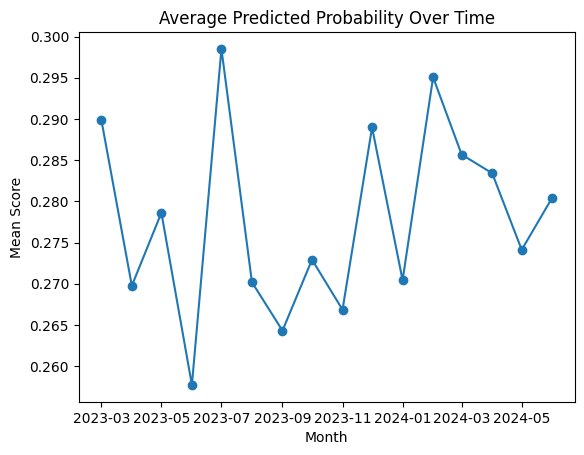

In [16]:
import matplotlib.pyplot as plt
predictions_pdf = df.toPandas()

# Mean prediction per month
score_summary = predictions_pdf.groupby("feature_snapshot_date")["model_predictions"].mean()
score_summary.plot(marker='o')
plt.title("Average Predicted Probability Over Time")
plt.xlabel("Month")
plt.ylabel("Mean Score")
plt.show()


In [5]:
folder_path = "datamart/gold/feature_store/"
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
feature_store_pdf = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",feature_store_pdf.count())

feature_store_pdf.show()

row_count: 7848


+-----------+-------------+---+-------------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+---------------------+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|Customer_ID|snapshot_date|Age|   Occupation|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|Credit_History_Mon

In [21]:
from pyspark.sql.functions import desc
feature_store_pdf.groupby("snapshot_date").count().orderBy(desc("snapshot_date")).show()
# feature_store_pdf.select(min("snapshot_date")).show()

+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|   2024-06-01|  422|
|   2024-05-01|  429|
|   2024-04-01|  441|
|   2024-03-01|  450|
|   2024-02-01|  452|
|   2024-01-01|  426|
|   2023-12-01|  434|
|   2023-11-01|  423|
|   2023-10-01|  422|
|   2023-09-01|  386|
|   2023-08-01|  425|
|   2023-07-01|  433|
|   2023-06-01|  457|
|   2023-05-01|  466|
|   2023-04-01|  436|
|   2023-03-01|  438|
|   2023-02-01|  442|
|   2023-01-01|  466|
+-------------+-----+

